Connected to scvi (Python 3.13.2)

In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# read in data
def preprocess_experiment(enhancer_file, vector_file):
    enhancer = pd.read_csv(enhancer_file)
    vector = pd.read_csv(vector_file)
    enhancer.index = enhancer['masks'].astype(str) + '_' + enhancer['fov'].astype(str)
    vector.index = vector['masks'].astype(str) + '_' + vector['fov'].astype(str)
    # find common index and filter
    common_index = enhancer.index.intersection(vector.index)
    enhancer = enhancer.loc[common_index]
    vector = vector.loc[common_index]
    # drop mask and fov columns
    enhancer_drop = enhancer.copy().drop(columns=['masks', 'fov'])
    vector_drop = vector.copy().drop(columns=['masks', 'fov'])
    result = {"enhancer": enhancer_drop, "vector": vector_drop,
              "enhancer_orig": enhancer, "vector_orig": vector}
    return result

def glm_fit(experiment, family=sm.families.Gaussian(), norm_by_total=False):
    # Create the model
    enhancer = experiment["enhancer"]
    vector = experiment["vector"]
    result = pd.DataFrame()
    if norm_by_total:
        enhancer = enhancer.div(enhancer.iloc[:, -1], axis=0)
        vector = vector.div(vector.iloc[:, -1], axis=0)
    for cre in enhancer.columns[:-1]:
        if cre not in vector.columns:
            raise ValueError(f"CRE {cre} not found in vector data.")
        glm_model = sm.GLM(enhancer[cre], vector[cre], family=family)
        # Fit the model
        glm_results = glm_model.fit()
        glm_summary = glm_results.summary()
        result = pd.concat([result, pd.read_html(glm_summary.tables[1].as_html(), header=0, index_col=0)[0]], axis=0)
    # do glm fit on poshen data
    poshen = pd.read_excel("data/Poshen_Table_S3.xlsx", sheet_name = "raw counts HCT116")
    poshen.set_index('oligo', inplace=True)
    poshen_deseq2 = pd.read_csv("data/HCT116_activating_oligo.csv")
    poshen_deseq2.index = poshen_deseq2['chr'].astype(str) + ":" + poshen_deseq2['start'].astype(int).astype(str) + "-" + poshen_deseq2['end'].astype(int).astype(str)
    ccre_names = pd.read_csv('data/20CRE.bed', header=None, sep='\t')
    ccre_names = ccre_names.astype(str)
    poshen = poshen.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen_deseq2 = poshen_deseq2.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    poshen_deseq2.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    # poshen fill missing values with NA
    poshen = poshen.reindex(result.index, fill_value=np.nan)
    poshen_deseq2 = poshen_deseq2.reindex(result.index, fill_value=np.nan)
    result['Poshen Activity'] = poshen['Activity'].values
    result['Poshen Activity DESeq2'] = poshen_deseq2['lfc'].values
    # rename result
    result = result.rename(columns={'coef': 'STARR-FISH Activity', 'std err': 'STARR-FISH Activity std err'})
    experiment['glm_fit_result'] = result
    return experiment

def glm_fit_total(experiment, family=sm.families.Gaussian(), norm_by_vector=True, norm_by_nanopore=False):
    # Create the model
    enhancer = experiment["enhancer"]
    vector = experiment["vector"]
    enh_result = pd.DataFrame()
    vec_result = pd.DataFrame()
    for cre in enhancer.columns[:-1]:
        if cre not in vector.columns:
            raise ValueError(f"CRE {cre} not found in vector data.")
        glm_model = sm.GLM(enhancer[cre], enhancer.iloc[:, -1], family=family)
        # Fit the model
        glm_results = glm_model.fit()
        glm_summary = glm_results.summary()
        enh_result = pd.concat([enh_result, pd.read_html(glm_summary.tables[1].as_html(), header=0, index_col=0)[0]], axis=0)
        glm_model = sm.GLM(vector[cre], vector.iloc[:, -1], family=family)
        # Fit the model
        glm_results = glm_model.fit()
        glm_summary = glm_results.summary()
        vec_result = pd.concat([vec_result, pd.read_html(glm_summary.tables[1].as_html(), header=0, index_col=0)[0]], axis=0)
    result = enh_result.copy()
    result.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(result))]
    if norm_by_vector:
        result['coef'] = result['coef'].values / vec_result['coef'].values
    if norm_by_nanopore:
        nanopore = pd.read_csv('data/SFv4_T7_20CRE_nanopore_counts', sep=' ', skipinitialspace=True, header=None)
        nanopore.set_index(1, inplace=True)
        result['nanopore'] = nanopore[0].loc[result.index].values
        result['coef'] = result['coef'].values / np.log(result['nanopore'].values)
    # do glm fit on poshen data
    poshen = pd.read_excel("data/Poshen_Table_S3.xlsx", sheet_name = "raw counts HCT116")
    poshen.set_index('oligo', inplace=True)
    poshen_deseq2 = pd.read_csv("data/HCT116_activating_oligo.csv")
    poshen_deseq2.index = poshen_deseq2['chr'].astype(str) + ":" + poshen_deseq2['start'].astype(int).astype(str) + "-" + poshen_deseq2['end'].astype(int).astype(str)
    ccre_names = pd.read_csv('data/20CRE.bed', header=None, sep='\t')
    ccre_names = ccre_names.astype(str)
    poshen = poshen.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen_deseq2 = poshen_deseq2.loc[(ccre_names[0] + ":" + ccre_names[1] + "-" + ccre_names[2])]
    poshen.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    poshen_deseq2.index = [f'CRE{str(i+1).zfill(3)}' for i in range(len(poshen))]
    # poshen fill missing values with NA
    poshen = poshen.reindex(result.index, fill_value=np.nan)
    poshen_deseq2 = poshen_deseq2.reindex(result.index, fill_value=np.nan)
    result['Poshen Activity'] = poshen['Activity'].values
    result['Poshen Activity DESeq2'] = poshen_deseq2['lfc'].values
    result = result.rename(columns={'coef': 'STARR-FISH Activity', 'std err': 'STARR-FISH Activity std err'})
    experiment['glm_fit_total_result'] = result
    return experiment

def plot_glm_results(glm_result, poshen_col='Poshen Activity', fig_name='glm_result.pdf'):
    glm_result = glm_result.dropna()
    sns.scatterplot(glm_result, x=poshen_col, y='STARR-FISH Activity', hue=glm_result.index)
    sns.regplot(glm_result, x=poshen_col, y='STARR-FISH Activity', scatter=False, color='red')
    slope, intercept, r, p, sterr = scipy.stats.linregress(x=glm_result['STARR-FISH Activity'], 
                                                           y=glm_result[poshen_col])
    plt.text(min(glm_result[poshen_col])*1.2, max(glm_result['STARR-FISH Activity'])*0.8, 'y = ' + str(round(intercept,3)) + ' + ' + str(round(slope,3)) + 'x\nr = ' + str(round(r,3)) + ', p = ' + str(round(p,3)), fontsize=10)
    plt.ylabel('STARR-FISH Activity')
    plt.legend([],[], frameon=False)
    # save figure
    plt.savefig(fig_name, bbox_inches='tight')
    return plt.gca()

def plot_activity(glm_result, value='STARR-FISH Activity', std='STARR-FISH Activity std err', fig_name='activity.pdf'):
    sns.scatterplot(data=glm_result, x=glm_result.index, y=value, hue=glm_result.index)  # `s` adjusts point size
    plt.errorbar(x=glm_result.index, y=glm_result[value], yerr=2*glm_result[std], 
                 fmt='none',  # Do not plot markers (already done by Seaborn)
                 ecolor='gray', elinewidth=1.5, capsize=5)
    plt.ylabel('STARR-FISH Activity')
    # rotate x ticks
    plt.xticks(rotation=45)
    # remove x label
    plt.xlabel('')
    plt.legend([],[], frameon=False)
    # save figure
    plt.savefig(fig_name, bbox_inches='tight')
    return plt.gca()

def plot_corr_experiments(experiment1, experiment2, key='glm_fit_result', value='STARR-FISH Activity', std='STARR-FISH Activity std err', fig_name='corr_experiment.pdf'):
    glm_res1 = experiment1[key].dropna().copy()
    glm_res2 = experiment2[key].dropna().copy()
    # rename value and std columns
    glm_res1 = glm_res1.rename(columns={value: f'{value}_rep1', std: f'{std}_rep1'})
    glm_res2 = glm_res2.rename(columns={value: f'{value}_rep2', std: f'{std}_rep2'})
    # merge dataframes
    glm_res = pd.merge(glm_res1, glm_res2, left_index=True, right_index=True)
    # scatter plot
    sns.scatterplot(glm_res, x=f'{value}_rep1', y=f'{value}_rep2', hue=glm_res.index)
    # plot regression line
    sns.regplot(glm_res, x=f'{value}_rep1', y=f'{value}_rep2', scatter=False, color='red')
    # calculate slope, intercept, r, p, sterr
    slope, intercept, r, p, sterr = scipy.stats.linregress(x=glm_res[f'{value}_rep1'], 
                                                           y=glm_res[f'{value}_rep2'])
    plt.text(min(glm_res[f'{value}_rep1'])*1.2, max(glm_res[f'{value}_rep2'])*0.8, 
             'y = ' + str(round(intercept,3)) + ' + ' + str(round(slope,3)) + 'x\nr = ' + str(round(r,3)) + ', p = ' + str(round(p,3)), fontsize=10)
    plt.legend([],[], frameon=False)
    # title
    plt.title(f'Correlation between {key} of two experiments')
    # save figure
    plt.savefig(fig_name, bbox_inches='tight')
    return plt.gca()

In [ ]:
july_experiment = preprocess_experiment('data/SFv4_T7_July_enhancer_cbg.csv', 'data/SFv4_T7_July_T7_cbg.csv')
sept_experiment = preprocess_experiment('data/SFv4_T7_Sept_enhancer_cbg.csv', 'data/SFv4_T7_Sept_T7_cbg.csv')
# fit glm
july_experiment = glm_fit(july_experiment, family=sm.families.Gaussian(), norm_by_total=False)
sept_experiment = glm_fit(sept_experiment, family=sm.families.Gaussian(), norm_by_total=False)
july_experiment = glm_fit_total(july_experiment, family=sm.families.Gaussian(), norm_by_vector=False, norm_by_nanopore=True)
sept_experiment = glm_fit_total(sept_experiment, family=sm.families.Gaussian(), norm_by_vector=False, norm_by_nanopore=True)

<Axes: xlabel='Poshen Activity', ylabel='STARR-FISH Activity'>

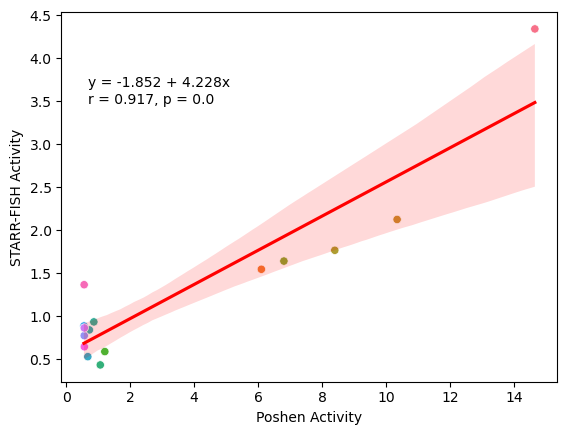

In [ ]:
plot_glm_results(july_experiment['glm_fit_result'], fig_name='fig/july_glm_result.pdf')

<Axes: ylabel='STARR-FISH Activity'>

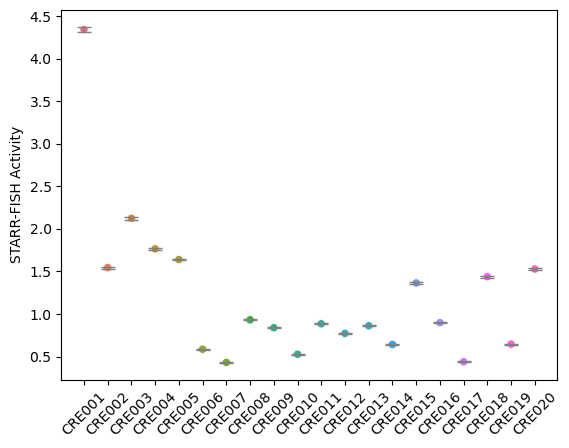

In [ ]:
plot_activity(july_experiment['glm_fit_result'], fig_name='fig/july_activity.pdf')

<Axes: xlabel='Poshen Activity DESeq2', ylabel='STARR-FISH Activity'>

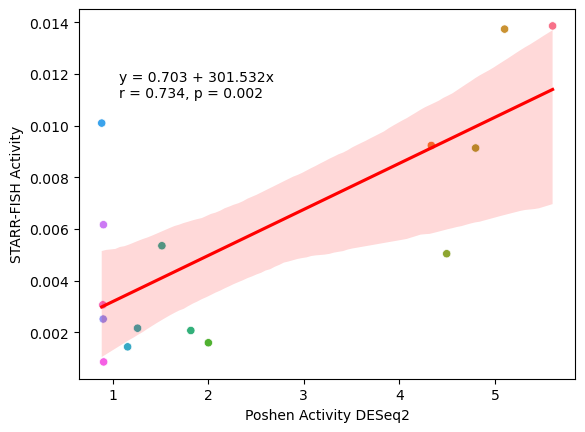

In [ ]:
plot_glm_results(july_experiment['glm_fit_total_result'], poshen_col='Poshen Activity DESeq2', fig_name='fig/july_glm_total_result.pdf')

<Axes: ylabel='STARR-FISH Activity'>

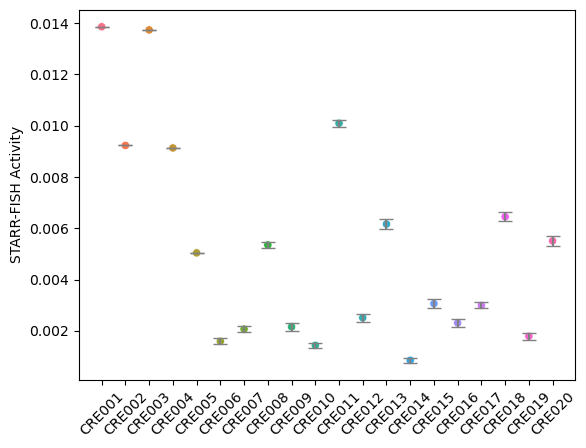

In [ ]:
plot_activity(july_experiment['glm_fit_total_result'], fig_name='fig/july_activity_total.pdf')

<Axes: xlabel='Poshen Activity', ylabel='STARR-FISH Activity'>

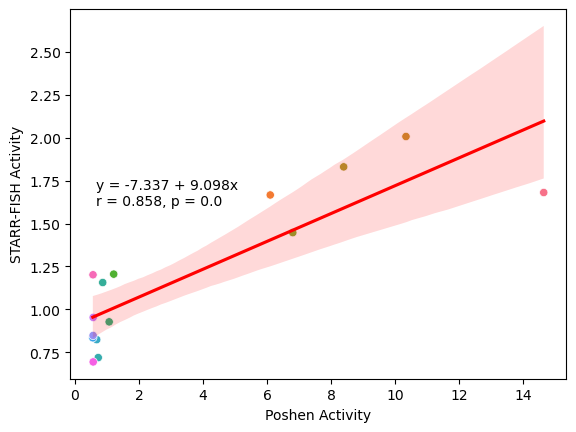

In [ ]:
plot_glm_results(sept_experiment['glm_fit_result'], fig_name='fig/sept_glm_result.pdf')

<Axes: ylabel='STARR-FISH Activity'>

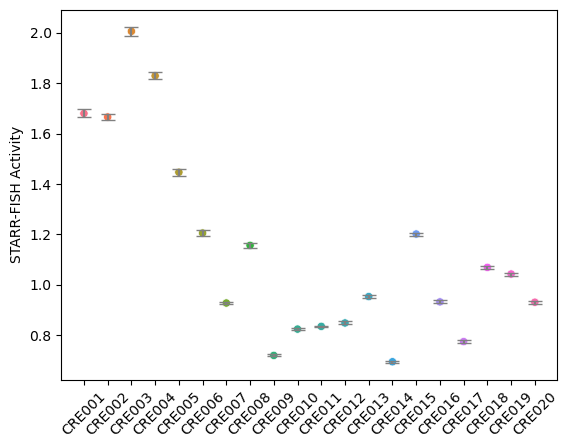

In [ ]:
plot_activity(sept_experiment['glm_fit_result'], fig_name='fig/sept_activity.pdf')

<Axes: xlabel='Poshen Activity DESeq2', ylabel='STARR-FISH Activity'>

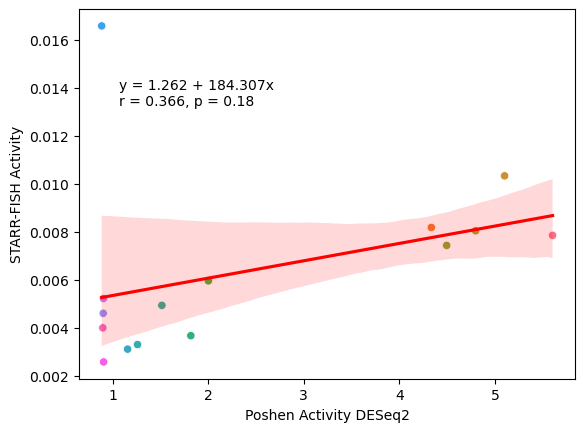

In [ ]:
plot_glm_results(sept_experiment['glm_fit_total_result'], poshen_col='Poshen Activity DESeq2', fig_name='fig/sept_glm_total_result.pdf')

<Axes: ylabel='STARR-FISH Activity'>

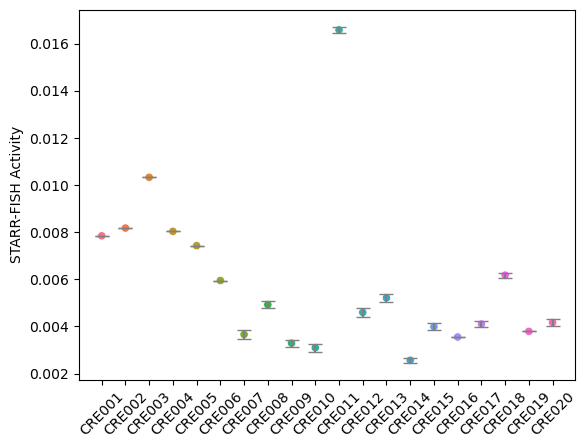

In [ ]:
plot_activity(sept_experiment['glm_fit_total_result'], fig_name='fig/sept_activity_total.pdf')

<Axes: title={'center': 'Correlation between glm_fit_result of two experiments'}, xlabel='STARR-FISH Activity_rep1', ylabel='STARR-FISH Activity_rep2'>

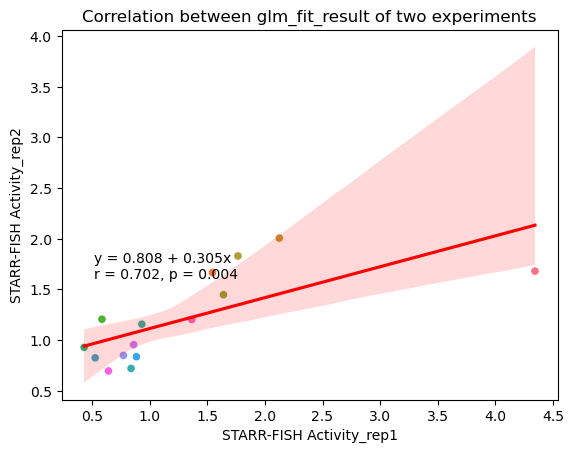

In [ ]:
plot_corr_experiments(july_experiment, sept_experiment, key='glm_fit_result', fig_name='fig/corr_experiment.pdf')

<Axes: title={'center': 'Correlation between glm_fit_total_result of two experiments'}, xlabel='STARR-FISH Activity_rep1', ylabel='STARR-FISH Activity_rep2'>

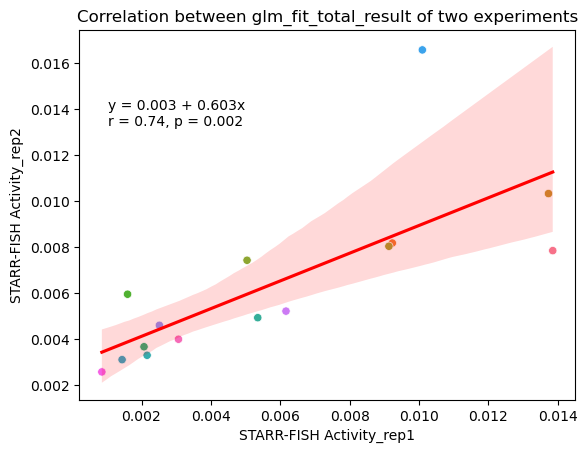

In [ ]:
plot_corr_experiments(july_experiment, sept_experiment, key='glm_fit_total_result', fig_name='fig/corr_experiment_total.pdf')